In [4]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

In [5]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
data = pd.read_csv("/content/Product_Feedback_1000.csv")

data.head()

,Feedback_ID,Product,Category,Rating,Feedback
0,1,Running Shoes,Sports,1,The battery drains very quickly during normal ...
1,2,Vacuum Cleaner,Home Appliances,2,The product is too expensive for its quality.
2,3,Running Shoes,Sports,4,The product quality is excellent and it is eas...
3,4,Wireless Earbuds,Electronics,3,The product quality is average and could be im...
4,5,Shampoo,Beauty,4,The usability is very good and the instruction...


In [8]:
print("Rows and Columns:", data.shape)

print("\nColumns:")
print(data.columns)

print("\nMissing Values:")
print(data.isnull().sum())

Rows and Columns: (1000, 5)

Columns:
Index(['Feedback_ID', 'Product', 'Category', 'Rating', 'Feedback'], dtype='object')

Missing Values:
Feedback_ID    0
Product        0
Category       0
Rating         0
Feedback       0
dtype: int64


In [9]:
print(data['Rating'].value_counts().sort_index())

Rating
1     80
2    132
3    200
4    318
5    270
Name: count, dtype: int64


In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [11]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [12]:
data['Clean_Feedback'] = data['Feedback'].apply(clean_text)

data[['Feedback', 'Clean_Feedback']].head()

,Feedback,Clean_Feedback
0,The battery drains very quickly during normal ...,battery drain quickly normal use
1,The product is too expensive for its quality.,product expensive quality
2,The product quality is excellent and it is eas...,product quality excellent easy use
3,The product quality is average and could be im...,product quality average could improved
4,The usability is very good and the instruction...,usability good instruction clear


In [13]:
def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

In [14]:
data['Sentiment'] = data['Clean_Feedback'].apply(get_sentiment)

data[['Feedback', 'Sentiment']].head()

,Feedback,Sentiment
0,The battery drains very quickly during normal ...,Positive
1,The product is too expensive for its quality.,Negative
2,The product quality is excellent and it is eas...,Positive
3,The product quality is average and could be im...,Negative
4,The usability is very good and the instruction...,Positive


In [15]:
print(data['Sentiment'].value_counts())

Sentiment
Positive    773
Negative    128
Neutral      99
Name: count, dtype: int64


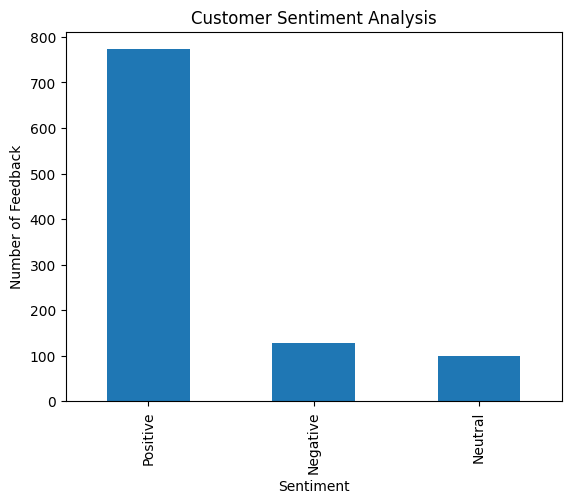

In [16]:
data['Sentiment'].value_counts().plot(kind='bar')

plt.title("Customer Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedback")

plt.show()

In [17]:
areas = [
    "quality",
    "price",
    "packaging",
    "delivery",
    "battery",
    "design",
    "durability",
    "usability",
    "performance"
]

In [18]:
area_count = {}

for word in areas:
    area_count[word] = data['Clean_Feedback'].str.contains(
        word,
        case=False
    ).sum()

print(area_count)

{'quality': np.int64(134), 'price': np.int64(109), 'packaging': np.int64(115), 'delivery': np.int64(22), 'battery': np.int64(29), 'design': np.int64(122), 'durability': np.int64(0), 'usability': np.int64(67), 'performance': np.int64(123)}


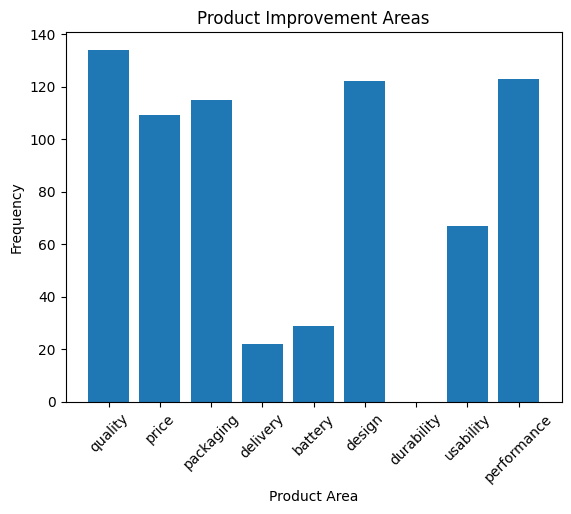

In [19]:
plt.bar(
    area_count.keys(),
    area_count.values()
)

plt.title("Product Improvement Areas")
plt.xlabel("Product Area")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

In [20]:
tfidf = TfidfVectorizer(max_features=20)

X = tfidf.fit_transform(data['Clean_Feedback'])

words = tfidf.get_feature_names_out()

scores = X.toarray().sum(axis=0)

result = pd.DataFrame({
    'Word': words,
    'Score': scores
})

result = result.sort_values(
    'Score',
    ascending=False
)

print(result)

           Word       Score
15      product  248.688217
17          use  124.698172
9   instruction  107.324015
13  performance  104.469099
16      quality   86.888741
4        design   85.027589
14        price   82.643724
5       durable   76.400426
7     excellent   73.654674
12    packaging   66.928339
19         work   66.728875
1        better   64.589702
2   comfortable   61.784675
0       arrived   58.426308
6          easy   54.129777
3         could   54.085794
11        offer   43.354319
10        money   43.354319
8         great   43.354319
18        value   43.354319


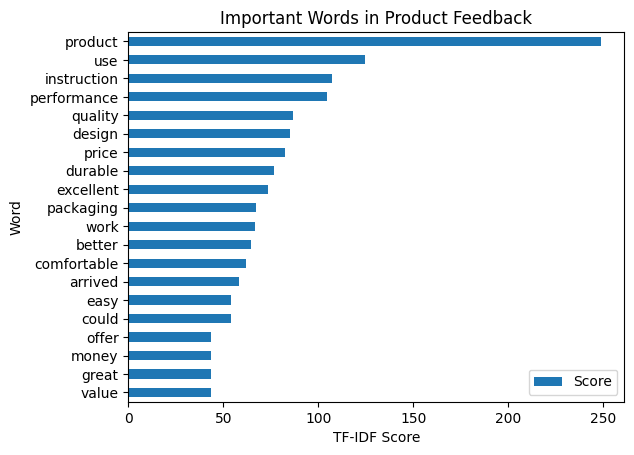

In [21]:
result.sort_values('Score').plot(
    x='Word',
    y='Score',
    kind='barh'
)

plt.title("Important Words in Product Feedback")
plt.xlabel("TF-IDF Score")

plt.show()

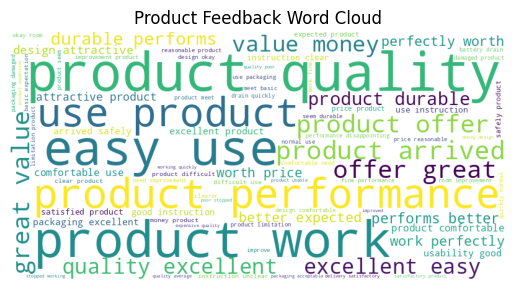

In [22]:
text = " ".join(data['Clean_Feedback'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Product Feedback Word Cloud")

plt.show()

In [23]:
sorted_areas = sorted(
    area_count.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Product Improvement Areas:")
print(sorted_areas)

Product Improvement Areas:
[('quality', np.int64(134)), ('performance', np.int64(123)), ('design', np.int64(122)), ('packaging', np.int64(115)), ('price', np.int64(109)), ('usability', np.int64(67)), ('battery', np.int64(29)), ('delivery', np.int64(22)), ('durability', np.int64(0))]


In [24]:
print("BUSINESS INSIGHTS")
print("Total Feedback:", len(data))

print("\nAverage Rating:",
      round(data['Rating'].mean(), 2))

print("\nSentiment Distribution:")
print(data['Sentiment'].value_counts())

print("\nMost Common Product Issues:")

for area, count in sorted_areas[:5]:
    print(area, ":", count)

BUSINESS INSIGHTS
Total Feedback: 1000

Average Rating: 3.57

Sentiment Distribution:
Sentiment
Positive    773
Negative    128
Neutral      99
Name: count, dtype: int64

Most Common Product Issues:
quality : 134
performance : 123
design : 122
packaging : 115
price : 109


In [25]:
print("PRODUCT IMPROVEMENT SUGGESTIONS")
print("1. Improve product quality and durability.")

print("2. Review product pricing based on customer feedback.")

print("3. Improve packaging to prevent damage.")

print("4. Improve product performance and usability.")

print("5. Address battery-related complaints.")

print("6. Improve product design based on customer expectations.")

print("7. Improve delivery experience.")

PRODUCT IMPROVEMENT SUGGESTIONS
1. Improve product quality and durability.
2. Review product pricing based on customer feedback.
3. Improve packaging to prevent damage.
4. Improve product performance and usability.
5. Address battery-related complaints.
6. Improve product design based on customer expectations.
7. Improve delivery experience.
